In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os

zip_path = "/content/drive/MyDrive/Brain Tumor Detection/Unzipped_BT.zip"
extract_path = "/content/Brain_Tumor_Classification"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Dataset extracted to /content successfully")

 Dataset extracted to /content successfully


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Brain Tumor Detection/Training',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Brain Tumor Detection/Testing',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# Augmentation Layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

Found 2720 files belonging to 4 classes.
Found 544 files belonging to 4 classes.


In [ ]:
base_model = tf.keras.applications.ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Start frozen

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.resnet_v2.preprocess_input), # Specific ResNet scaling
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # High dropout to force the model to learn hard features
    layers.Dense(4, activation='softmax')
])

In [ ]:
# Phase 1: Training
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

print("Phase 1: Warming up the top layers...")
model.fit(train_ds, validation_data=val_ds, epochs=3)

# Phase 2: Training to fine tune
base_model.trainable = True
# Freeze early layers, leave top 50 for MRI specialization
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), # Tiny learning rate
              loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks to catch the best accuracy
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]

print("\nPhase 2: Deep training for Medical Grade Accuracy...")
history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

Phase 1: Warming up the top layers...
Epoch 1/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 26s 194ms/step - accuracy: 0.5827 - loss: 1.1564 - val_accuracy: 0.6360 - val_loss: 0.8884
Epoch 2/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.7794 - loss: 0.6173 - val_accuracy: 0.6875 - val_loss: 0.8495
Epoch 3/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.7990 - loss: 0.5295 - val_accuracy: 0.6893 - val_loss: 0.8287

Phase 2: Deep training for Medical Grade Accuracy...
Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 35s 242ms/step - accuracy: 0.5956 - loss: 0.9920 - val_accuracy: 0.5699 - val_loss: 1.1542 - learning_rate: 1.0000e-05
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - accuracy: 0.8323 - loss: 0.5035 - val_accuracy: 0.6765 - val_loss: 0.8841 - learning_rate: 1.0000e-05
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.8492 - loss: 0.4224 - val_accuracy: 0.7500 - val_loss: 0.7408 - learning_rate: 1.0000e-05
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step 


--- Medical Classification Report ---
                  precision    recall  f1-score   support

    glioma_tumor       0.95      0.79      0.86       175
meningioma_tumor       0.90      0.86      0.88       190
        no_tumor       0.80      0.98      0.88       105
 pituitary_tumor       0.74      0.88      0.80        74

        accuracy                           0.86       544
       macro avg       0.85      0.88      0.86       544
    weighted avg       0.87      0.86      0.86       544



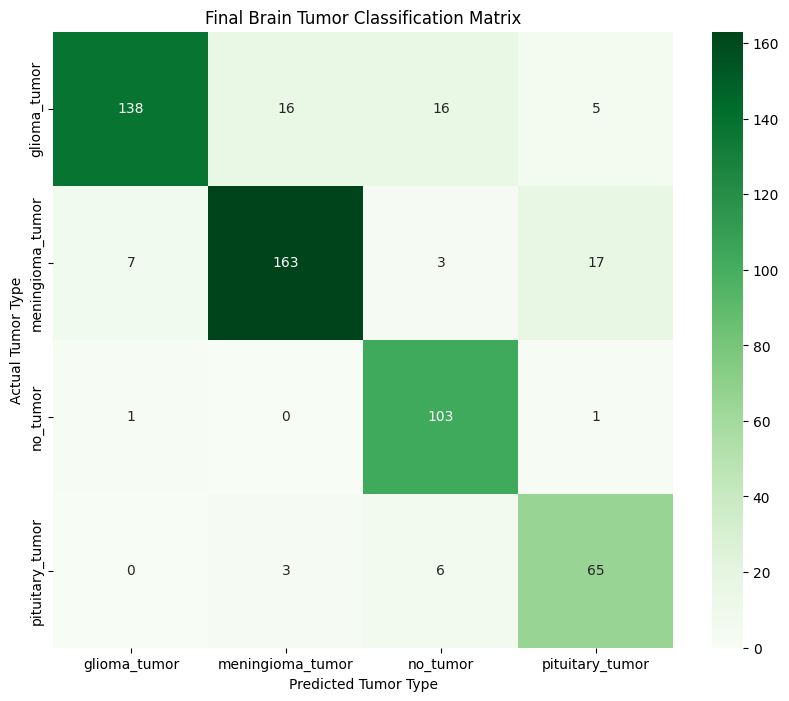

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gather all true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Print the text report
print("\n--- Medical Classification Report ---")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

# 3. Plot a clean Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=val_ds.class_names,
            yticklabels=val_ds.class_names)
plt.title('Final Brain Tumor Classification Matrix')
plt.ylabel('Actual Tumor Type')
plt.xlabel('Predicted Tumor Type')
plt.show()

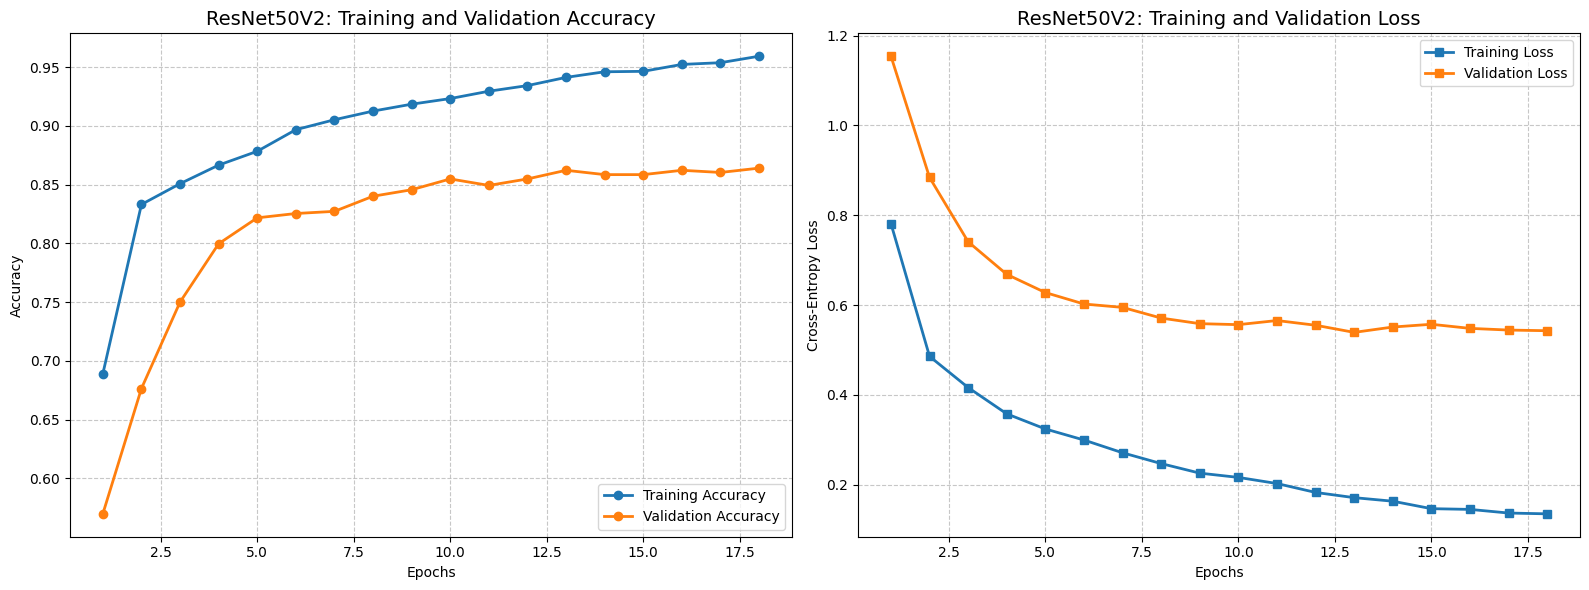

In [ ]:
import matplotlib.pyplot as plt

def plot_medical_training_history(history):
    # Extract data from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Create a clean, professional figure
    plt.figure(figsize=(16, 6))

    # --- Plot 1: Accuracy Over Time ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', marker='o', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', marker='o', linewidth=2)
    plt.title('ResNet50V2: Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 2: Loss Over Time ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', marker='s', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', marker='s', linewidth=2)
    plt.title('ResNet50V2: Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Call the function
plot_medical_training_history(history)

In [ ]:
import os
from google.colab import drive

# Mount drive if not already done
drive.mount('/content/drive')

# Create a folder for your results
save_path = '/content/drive/MyDrive/Brain_Tumor_Project_Results/'
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"Created folder: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created folder: /content/drive/MyDrive/Brain_Tumor_Project_Results/


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from PIL import Image
import matplotlib.pyplot as plt

def predict_png_mri(img_path):
    # 1. Load the image using PIL to handle PNG transparency/channels
    img = Image.open(img_path).convert('RGB')

    # 2. Resize to 224x224 (ResNet standard)
    img = img.resize((224, 224))

    # 3. Convert to array and add batch dimension
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # 4. ResNetV2 Specific Preprocessing
    # This scales pixels to the [-1, 1] range
    img_preprocessed = tf.keras.applications.resnet_v2.preprocess_input(img_array)

    # 5. Get Prediction
    predictions = model.predict(img_preprocessed, verbose=0)

    # 6. Map to Class Names
    class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx] * 100

    # 7. Display Result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Result: {class_names[predicted_idx]}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

# --- RUN TEST ---
# Replace with a path to one of your PNG files
# predict_png_mri('/content/drive/MyDrive/Brain Tumor Detection/Test image.png')

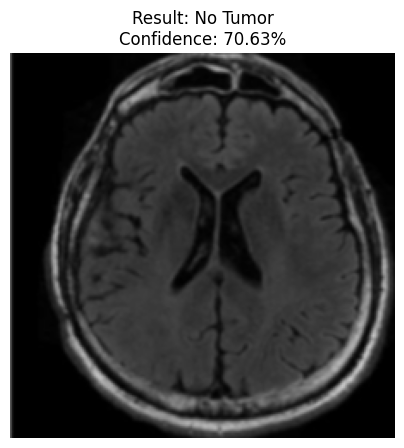

In [ ]:
# 1. Define the path to your image
# Tip: In Colab, right-click the image in the left sidebar and select "Copy path"
my_image_path = '/content/drive/MyDrive/Brain Tumor Detection/Test image new.png'

# 2. Call the function we created
predict_png_mri(my_image_path)

In [ ]:
def predict_with_cropping(img_path):
    # 1. Automatic Crop
    cropped_img_cv = crop_brain_contour(img_path)

    # 2. Convert BGR (OpenCV) to RGB (PIL/Keras)
    cropped_img_rgb = cv2.cvtColor(cropped_img_cv, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(cropped_img_rgb)

    # 3. Resize to model's requirement
    img_resized = img_pil.resize((224, 224))

    # 4. Standard Preprocessing
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_preprocessed = tf.keras.applications.resnet_v2.preprocess_input(img_array)

    # 5. Predict
    predictions = model.predict(img_preprocessed, verbose=0)
    class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx] * 100

    # 6. Result Visualization
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_resized)
    plt.title(f"Cropped & Predicted: {class_names[predicted_idx]}\nConf: {confidence:.2f}%")
    plt.axis('off')

    plt.show()

# TEST IT NOW
# predict_with_cropping('/content/drive/MyDrive/Brain Tumor Detection/Test image new.png')

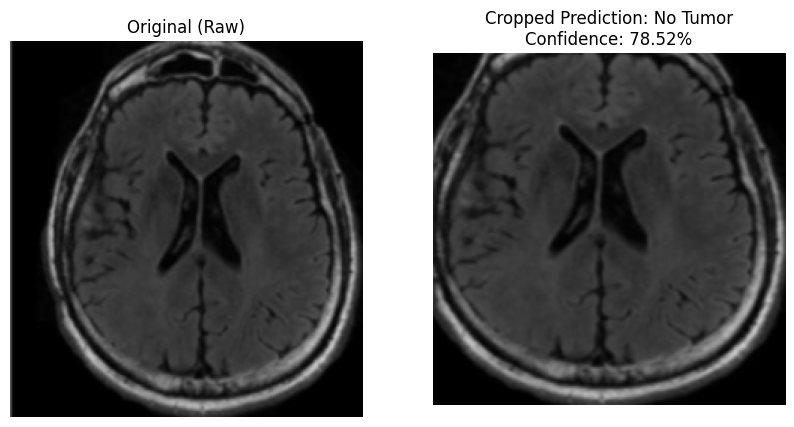

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from PIL import Image
import matplotlib.pyplot as plt
import os

# --- STEP 1: Define the Cropping Function ---
def crop_brain_contour(img_path):
    image_cv = cv2.imread(img_path)
    if image_cv is None:
        return None

    gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Separate brain from black background
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]

    if not cnts:
        return image_cv

    c = max(cnts, key=cv2.contourArea)
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    new_image = image_cv[extTop[1]:extBot[1], extLeft[0]:extRight[0]]
    return new_image

# --- STEP 2: Define the Prediction Function ---
def predict_with_cropping(img_path):
    # 1. Automatic Crop
    cropped_img_cv = crop_brain_contour(img_path)

    if cropped_img_cv is None:
        print("Error: Could not load image. Check the path.")
        return

    # 2. Convert BGR to RGB and Resize
    cropped_img_rgb = cv2.cvtColor(cropped_img_cv, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(cropped_img_rgb)
    img_resized = img_pil.resize((224, 224))

    # 3. Preprocessing for ResNet50V2
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_preprocessed = tf.keras.applications.resnet_v2.preprocess_input(img_array)

    # 4. Predict
    predictions = model.predict(img_preprocessed, verbose=0)
    class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx] * 100

    # 5. Show Results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.title("Original (Raw)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_resized)
    plt.title(f"Cropped Prediction: {class_names[predicted_idx]}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

# --- STEP 3: RUN IT ---
image_to_test = '/content/drive/MyDrive/Brain Tumor Detection/Test image new.png'
predict_with_cropping(image_to_test)